### 1. Image Loading

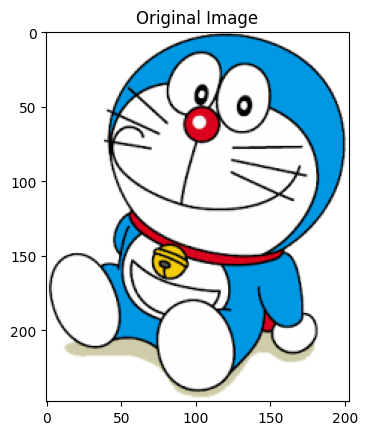

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("./images/doreamon/img1.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.show()

### 2. Image Resizing

- Models require same size images.
- Why?

Different images have different sizes.

In [2]:
print("Original size",img.shape)
img_resized = cv2.resize(img,(128,128))
print("updated size",img_resized.shape)

Original size (248, 203, 3)
updated size (128, 128, 3)


### 3. Convert to Grayscale

- Sometimes color information is unnecessary.

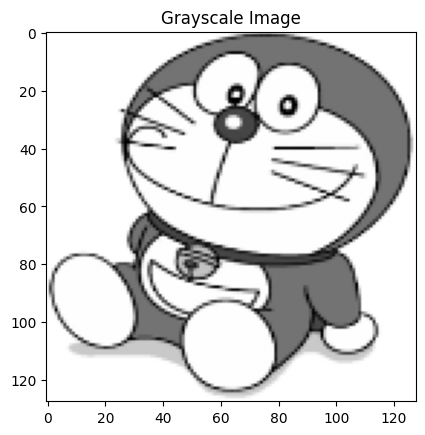

In [3]:
gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.show()

**Advantages:**

- Reduces computation
- Removes color noise

### 4. Image Normalization

- Pixel values normally range:
    - `0 – 255`
- But ML models prefer:
    - `0-1`

In [5]:
img_normalized = img_resized / 255.0


### 5. Noise Removal (Blurring)

Images often contain noise.

### GaussianBlur
- `cv2.GaussianBlur()` applies a Gaussian filter to an image, which smooths the image by giving **more weight to the center pixels and less weight to distant pixels.**
- Instead of averaging all neighboring pixels equally (like normal blur), Gaussian blur uses weighted averaging.

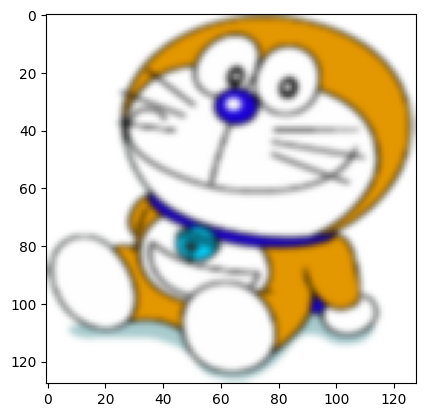

In [10]:
# This smooths the image.
blur = cv2.GaussianBlur(img_resized,(5,5),0)
plt.imshow(blur)

### 6. Edge Detection

Useful in object detection.

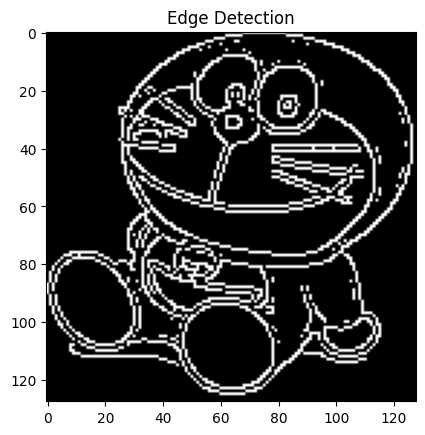

In [11]:
edges = cv2.Canny(gray,100,200)

plt.imshow(edges,cmap="gray")
plt.title("Edge Detection")
plt.show()

### 7. Image Flattening

ML models require 1D numerical input.

In [12]:
# 128 × 128 --> 16384 features
flat = gray.flatten()

## Creating a Dataset from Images

Now convert images into a DataFrame.

In [33]:
import os
import pandas as pd
data = []
labels = []

path = "images"

for label in os.listdir(path):

    folder = os.path.join(path,label)

    for file in os.listdir(folder):

        img_path = os.path.join(folder,file)

        img = cv2.imread(img_path)

        img = cv2.resize(img,(64,64))

        gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

        img_flat = gray.flatten()

        data.append(img_flat)
        labels.append(label)

df = pd.DataFrame(data)

df["label"] = labels

print(df.shape)
df.head()

(9, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,label
0,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,doreamon
1,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,doreamon
2,171,171,171,171,171,171,171,171,171,171,...,136,136,136,136,136,136,136,136,136,doreamon
3,83,83,82,85,87,90,92,96,98,101,...,84,84,80,90,81,125,127,125,113,ram
4,236,236,236,236,236,236,236,236,236,236,...,154,154,154,154,154,154,154,154,154,ram


In [29]:
64*64

4096

In [31]:
os.listdir("./images")

['doreamon', 'sinchan']

In [32]:
os.path.join(path,label)

'images\\sinchan'